# Heart Disease Prediction EDA & Preprocessing

### This notebook performs exploratory data analysis (EDA) and preprocessing for a classification task predicting heart disease.

In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Dataset Overview
In this section we will dive into the dataset.

In [125]:
heart_disease = fetch_ucirepo(id=45)
df = heart_disease.data.features.copy()
df['target'] = heart_disease.data.targets
print("First 5 rows of dataset:")
print(df.head())

First 5 rows of dataset:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  target  
0  0.0   6.0       0  
1  3.0   3.0       2  
2  2.0   7.0       1  
3  0.0   3.0       0  
4  0.0   3.0       0  


# Interpretation 
+ age: Patient’s age in years
+ sex: 0 = female, 1 = male
+ cp: Chest pain type (1–4)
+ trestbps: Resting blood pressure (mm Hg)
+ chol: Serum cholesterol (mg/dl)
+ fbs: 0 = ≤120 mg/dl, 1 = >120 mg/dl (fasting blood sugar)
+ restecg: Resting ECG results (0–2)
+ thalach: Maximum heart rate achieved
+ exang: 0 = no, 1 = yes (exercise induced angina)
+ oldpeak: ST depression induced by exercise
+ slope: Slope of peak exercise ST segment (1–3)
+ ca: Number of major vessels (0–3) colored by fluoroscopy
+ thal: Thalassemia type (3 = normal, 6 = fixed defect, 7 = reversible defect)
+ target: Heart disease presence/severity (0 = no, 1–4 = mild to severe)


In [126]:
print("\nDataset shape (rows, columns):", df.shape)
print("\nColumn names and data types:")
print(df.info())


Dataset shape (rows, columns): (303, 14)

Column names and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB
None


In [127]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
target        int64
dtype: object

In [128]:

print("\nQuick statistics for numeric columns:")
print(df.describe())


Quick statistics for numeric columns:
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    3.158416  131.689769  246.693069    0.148515   
std      9.038662    0.467299    0.960126   17.599748   51.776918    0.356198   
min     29.000000    0.000000    1.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    3.000000  120.000000  211.000000    0.000000   
50%     56.000000    1.000000    3.000000  130.000000  241.000000    0.000000   
75%     61.000000    1.000000    4.000000  140.000000  275.000000    0.000000   
max     77.000000    1.000000    4.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  299.000000   
mean     0.990099  149.607261    0.326733    1.039604    1.600660    

In [129]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


# Interpretation:

+ The dataset contains 303 observations and 14 features describing medical
attributes of patients.
+ All variables are numerical, although some represent categorical information
such as chest pain type (cp), thalassemia (thal), and exercise-induced angina (exang).
+ There are a small number of missing values in the dataset: 4 in the 'ca' column
and 2 in the 'thal' column. This small amount of missing data can be handled easily and is unlikely to significantly affect analysis or modeling.
+ The target variable is binary, indicating the presence (1) or absence (0) of heart
disease.
+ From the summary statistics, most patients are between 48 and 61 years old,
and cholesterol levels vary widely, suggesting potential variability in risk factors.

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


Text(0.5, 1.0, 'Class Distribution')

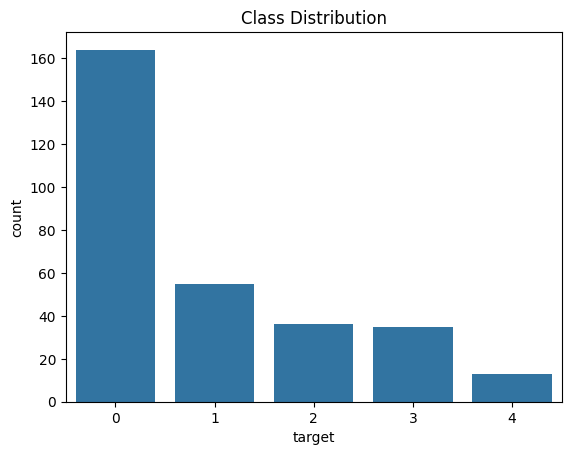

In [130]:
print(df['target'].value_counts())
sns.countplot(x='target', data=df)
plt.title('Class Distribution')

# Interpretation:
### Here, we can see that most patients in the dataset do not have heart disease. However, among the patients who do have heart disease, the majority have mild heart disease.

# Visualisation

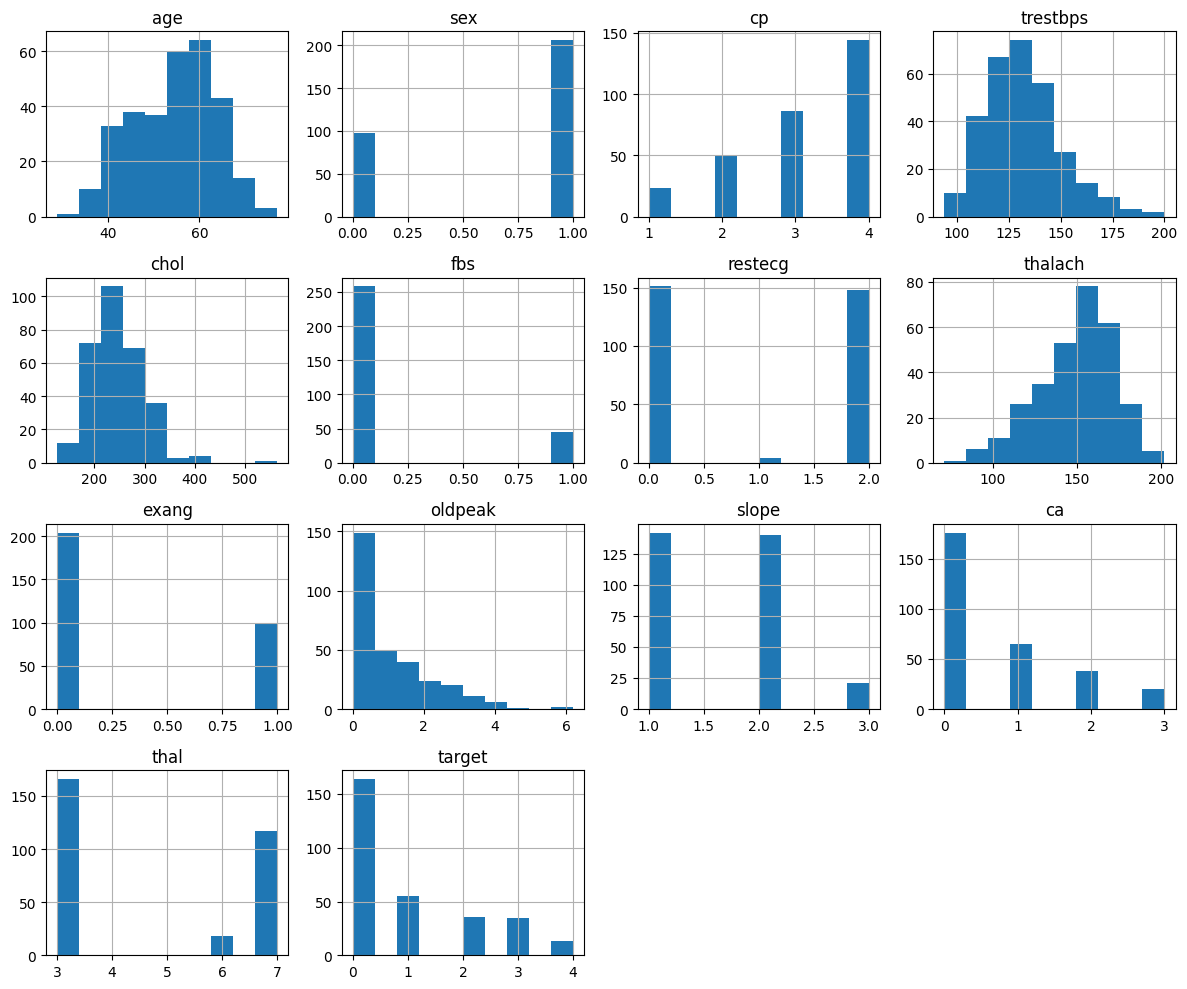

In [131]:
# Histogram fot numeric features
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols].hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

### Each histogram represents the distribution of a numeric feature in our dataset. We can quickly see the range, spread, and skewness of each column.
### For example, looking at the age histogram:
+ Most patients with heart disease are between 40 and 60 years old, showing that middle-aged people are more affected.
+ There are fewer patients below 40 or above 70, indicating that heart disease is less common in younger and older patients in this dataset.

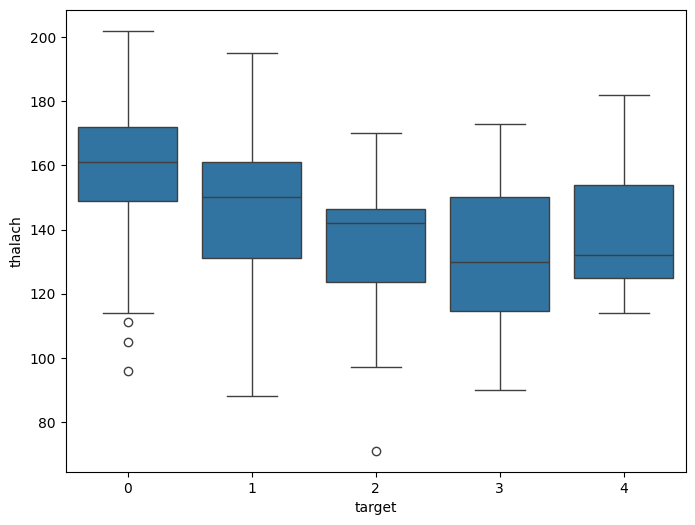

In [132]:
# Boxplot of thalach by target
plt.figure(figsize=(8, 6))
sns.boxplot(x='target', y='thalach', data=df)
plt.show()

# Interpretation:
+ Patients with no heart disease (0) generally have higher thalach (median around 160 bpm).
+ As the target value increases (mild → severe heart disease), the median thalach decreases:
- Category 2 → median ~142 bpm
- Category 3 → median ~130 bpm
- Category 4 → median ~132 bpm
+ Lower maximum heart rate is associated with higher heart disease severity.
+ Outliers (dots) indicate some patients have unusually low or high heart rates compared to others in that category.

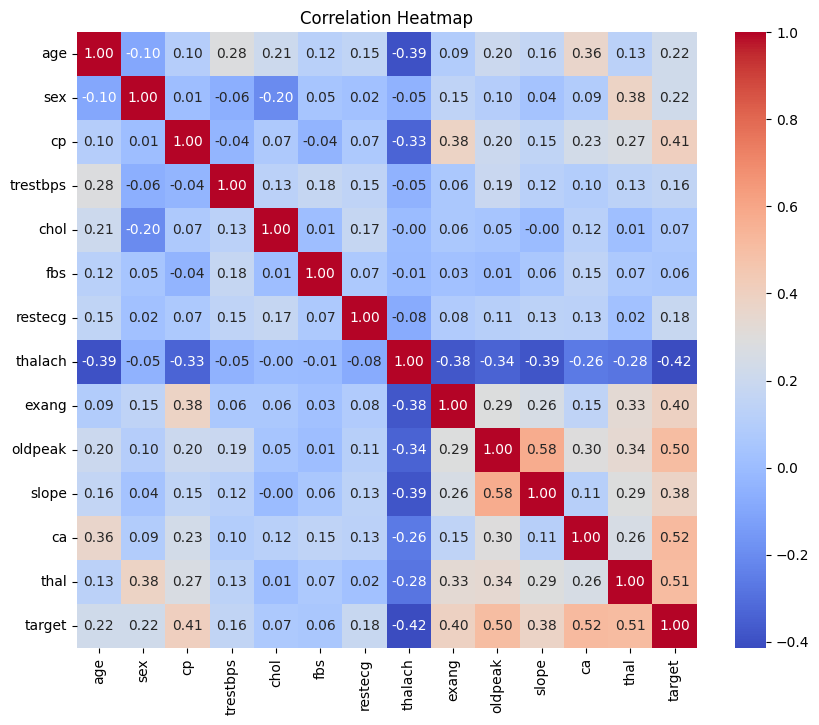

In [133]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

The heatmap shows that chest pain type (cp) and maximum heart rate (thalach) have a stronger relationship with the target compared to other features. This means these variables may be more important for predicting heart disease. Overall, we can conclude that some features are more influential than others, especially cp and thalach.

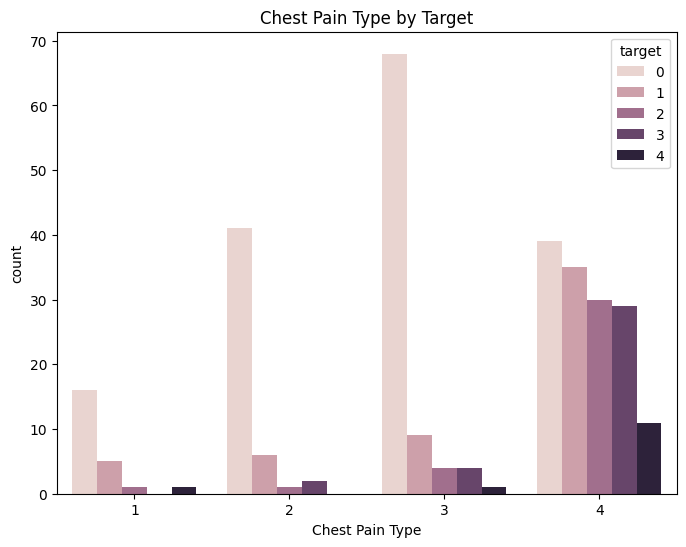

In [134]:
# Countplot for target variable
plt.figure(figsize=(8, 6))
sns.countplot(x='cp', hue='target', data=df)
plt.title('Chest Pain Type by Target')
plt.xlabel('Chest Pain Type')
plt.show()

The plot indicates that chest pain type is related to the presence and severity of heart disease. Typical angina is mostly observed in patients without heart disease, while asymptomatic patients show higher proportions of mild to severe disease. This suggests that absence of chest pain does not necessarily mean absence of heart disease.

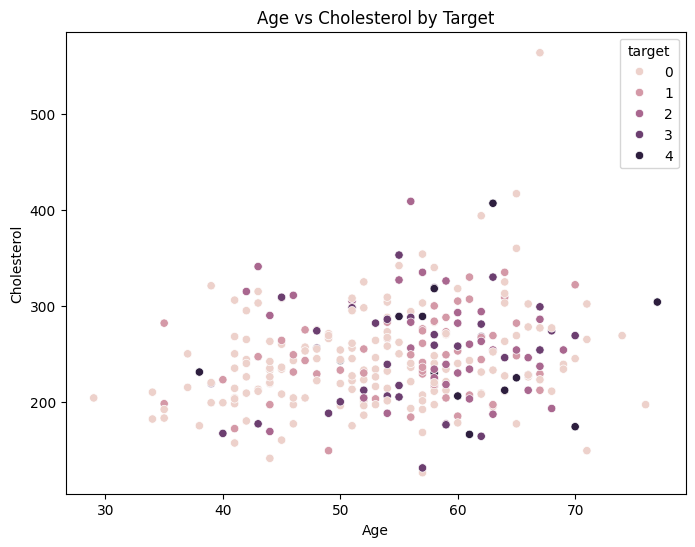

In [135]:
# Scatter plot of age vs chol colored by target
plt.figure(figsize=(8, 6))
sns.scatterplot(x='age', y='chol', hue='target', data=df)
plt.title('Age vs Cholesterol by Target')
plt.xlabel('Age')
plt.ylabel('Cholesterol')
plt.show()

 The scatter plot shows that age and cholesterol are related to heart disease risk. Younger patients mostly have no disease, while middle-aged and older patients show higher incidence. High cholesterol is often associated with heart disease, but age remains a strong factor.

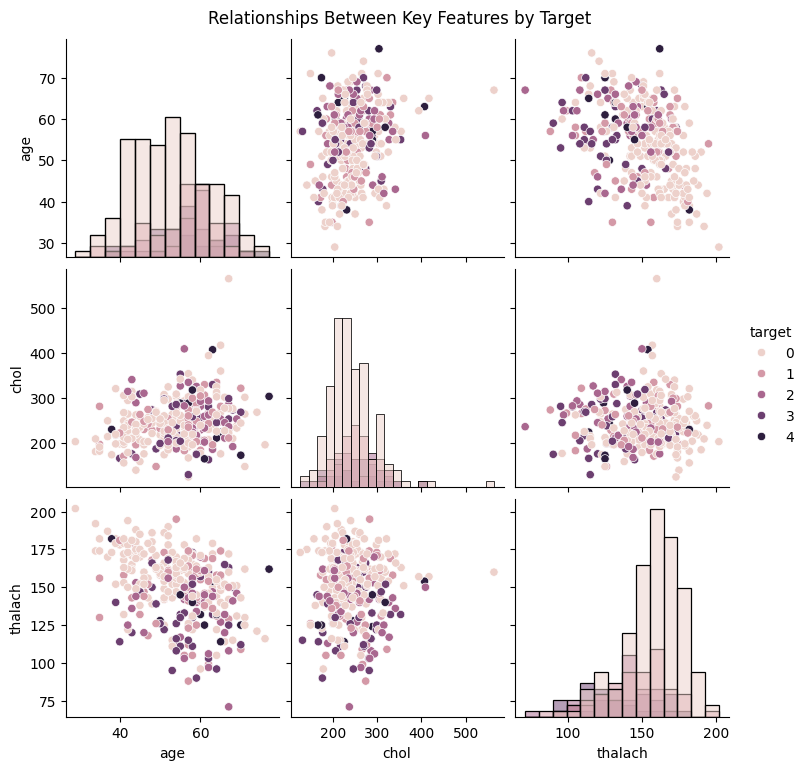

In [136]:
# Pairplot of key features colored by target
sns.pairplot(
    df[['age', 'chol', 'thalach', 'target']],
    hue='target',
    diag_kind='hist'
)
plt.suptitle('Relationships Between Key Features by Target', y=1.02)
plt.show()

The pairplot provides a visual comparison of the relationships between important numerical features such as age, cholesterol, and maximum heart rate across different target classes. It helps identify possible patterns and separations between patients with and without heart disease. From the plot, age and maximum heart rate appear to have noticeable differences across target categories, suggesting that these variables may be important predictors in the machine learning model.

# Missing Value Handling 

### From the missing value check, only the ca and thal columns contained missing values, with 4 and 2 missing entries respectively. Since both columns represent discrete/categorical medical features, the missing values were replaced using the mode (most frequent value). This strategy was chosen because it preserves the most common category in the dataset and avoids losing rows by dropping data. After imputation, all columns contained zero missing values.

In [137]:
# Fill missing values in categorical/discrete columns
df['ca'] = df['ca'].fillna(df['ca'].mode()[0])
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])

# Check again
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


# Feature Engineering 

In [138]:
# One-hot encoding categorical features
df_encoded = pd.get_dummies(
    df,
    columns=['cp', 'restecg', 'slope', 'ca', 'thal'],
    drop_first=True
)

# Optional: create age groups
df_encoded['age_group'] = pd.cut(
    df['age'],
    bins=[0, 40, 55, 100],
    labels=['Young', 'Middle', 'Old']
)
df_encoded = pd.get_dummies(df_encoded, columns=['age_group'], drop_first=True)

df_encoded.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,target,cp_2,...,restecg_2,slope_2,slope_3,ca_1.0,ca_2.0,ca_3.0,thal_6.0,thal_7.0,age_group_Middle,age_group_Old
0,63,1,145,233,1,150,0,2.3,0,False,...,True,False,True,False,False,False,True,False,False,True
1,67,1,160,286,0,108,1,1.5,2,False,...,True,True,False,False,False,True,False,False,False,True
2,67,1,120,229,0,129,1,2.6,1,False,...,True,True,False,False,True,False,False,True,False,True
3,37,1,130,250,0,187,0,3.5,0,False,...,False,False,True,False,False,False,False,False,False,False
4,41,0,130,204,0,172,0,1.4,0,True,...,True,False,False,False,False,False,False,False,True,False


Categorical features such as cp, restecg, slope, ca, and thal were encoded using one-hot encoding. These features represent categories rather than numerical values, so encoding them prevents the model from incorrectly assuming an ordinal relationship between the numbers. One-hot encoding is suitable here because the number of categories is small, and the planned models (e.g., logistic regression or tree-based models) can effectively use binary features.
Additionally, a new feature age_group was created by binning patients’ ages into categories (Young, Middle, Old). This feature captures the effect of age ranges on heart disease risk and may help the model detect patterns that are not obvious from raw age values alone.

# Scaling & Preprocessing 

In [139]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

# 1) Split the data first (train/test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2) Identify numerical columns to scale
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# 3) Initialize scaler
scaler = StandardScaler()

# 4) Fit scaler only on training data
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

# 5) Transform test data using the same scaler
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# 6) Confirm shapes
print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape: (242, 22)
X_test shape:  (61, 22)
y_train shape: (242,)
y_test shape:  (61,)


Numerical features (age, trestbps, chol, thalach, oldpeak) were scaled using StandardScaler, which centers values to mean 0 and scales them to unit variance. This ensures that features with larger ranges do not dominate the learning process of models sensitive to feature magnitude, like Logistic Regression or KNN. The scaler was fitted only on the training data after performing the train/test split, and the same transformation was applied to the test set to avoid data leakage.
The dataset was split using train_test_split with 20% for testing and random_state=42 to ensure reproducibility. The shapes of X_train, X_test, y_train, and y_test were printed and confirmed, ensuring the split was successful and the data is ready for model training and evaluation.

# Train/Test Split 

In [140]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

# Split the data (20% test, reproducible)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Print shapes to confirm
print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape: (242, 22)
X_test shape:  (61, 22)
y_train shape: (242,)
y_test shape:  (61,)


The dataset was split into training and test sets using train_test_split with 20% of the data reserved for testing and random_state=42 to ensure reproducibility. The shapes of X_train, X_test, y_train, and y_test were printed and confirmed.